In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from sympy import Symbol, Eq,exp, sqrt, lambdify
from sympy import exp, sqrt, Max
from scipy.optimize import fsolve
import xarray as xr
from Emmanuel_scheme import Temp_prof,met_profiles,T_v,w_parcel
from GB84 import variables_2, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter_2 import kalman_filter as kf

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
measurements = xr.open_mfdataset(r'cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

slice_str = "2024-07-09 00:00:00, 2024-07-09 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

In [3]:
#var = ['temperature','pressure','humidity','rain_rate']
var = ['TA002','P0','TD002','RH002']
measurements = measurements[var]
measurements = measurements.dropna(dim='time',how='any')
measurements_used = measurements.sel(time=slice(*slice_tuple))

In [4]:
parsivel_1 = xr.open_dataset(r'data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values

rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=measurements.time,method='nearest')

In [5]:
#kf_measurements = rain_rate.isel(time=slice(None, None, 6))
kf_measurements_used = rain_rate.sel(time=slice(*slice_tuple))

In [6]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = 0   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

modis_press = 487.17*100 #Pa

In [7]:
#loop for finding the precipitation given the T_0 and p
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
t_lower =0
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
j = 0
Q = 0.32
storm_ind = np.zeros(len(T_surf))
storm_ind_2 = np.zeros(len(T_surf))
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s = variables_2.calculate_cloud_base(T_0, T_d, p_0)
    if i == 0:
        p_t = modis_press
    
    #implementing the emmanuel scheme
    p_air,T_air = met_profiles(T_0,p_0,p_t)
    T_arr,lcl_index = Temp_prof(T_0,p_0,T_d,p_air,T_air)
    v_updr,cape = w_parcel(p_t,p_s,T_v(T_0,p_0,p_air,T_arr,lcl_index),T_air,lcl_index)
    v_updr = v_updr/2
    if cape>1000:
        storm_ind[i] = 1
    else:
        storm_ind[i] = 0
    if cape>1500:
        storm_ind_2[i] = 1
    else:
        storm_ind_2[i] = 0
    p_t, T_m, T_t,T_s_up, p_s_up = variables_2(T_0, T_d, p_0,v_updr, obs=False).run()[2:]

    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    rho = rho_m(T_s,T_t,p_s,p_t)
    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
        
    h_arr[i] = h_out(v_updr/2,Z_c).run()[2]
    #precipitation in kg/m2/s
    P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i] #*X[i] if we are using the updated state
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3600)
    #state without Kalman filter
    
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>=0:

        if i<(len(T_surf)-1):
            print(np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            X[i+1] = max(0,X[i] + (np.trapz([f_arr[j:i+1]], dx=dt)) - np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            Sigma[i+1] = Sigma[i] + 2*np.trapz([h_arr[j:i+1]*Sigma[j:i+1]], dx=dt) + Q*dt*(i - j)
            
        if (((i%6)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X[i], Sigma[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[j].values) 
            X[i+1],Sigma[i+1],X_apr = kalman_f.update()
            #print(X[i],X_apr)


        #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
        #P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]
        


2.5418680370562625
[0.]
3.218534083003596
[0.]
2.9445487030301187
[1.14942162]
2.7430166456610485
[5.95656119]
2.7613388292262258
[16.89717511]
2.97853191694691
[35.70444339]
3.2010769975481694
[63.59697515]
6
3.1843955481120867
[32.71230179]
3.117210935708725
[66.3853459]
3.258138778075115
[102.28285995]
3.1777239869517544
[141.97741792]
3.062085098677287
[187.76421383]
3.052282555730711
[240.94666661]
12
3.022695858853491
[56.99774017]
2.9565759662441526
[114.75660367]
2.580875907558633
[176.4503883]
2.4614933645260555
[243.71875812]
2.3231546432091337
[316.33089178]
2.329617811260509
[393.69253309]
18
2.2809663558401185
[77.2170188]
2.053774651529165
[154.71504451]
1.8063845121764373
[237.54712658]
1.657708763776906
[325.44383309]
1.922948914964528
[411.35083153]
2.312233069181861
[488.29102677]
24
2.2711793454793368
[67.20357307]
2.481483579849353
[128.30148378]
2.4105062128760575
[188.86530553]
2.4973358148830895
[250.3780615]
2.4455660536727564
[313.35296405]
2.0599015026421523
[

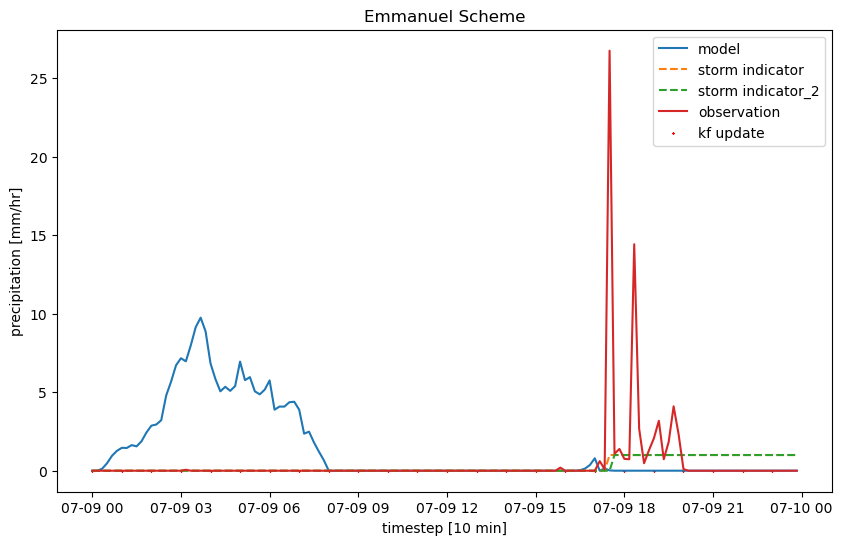

In [8]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))

plt.plot(measurements_used.time,P*3600,label='model')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(measurements_used.time,storm_ind,label='storm indicator',linestyle='--')
plt.plot(measurements_used.time,storm_ind_2,label='storm indicator_2',linestyle='--')
#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(measurements_used.time,rain_rate.sel(time=slice(*slice_tuple)),label='observation')
plt.scatter(measurements_used.time[0::6],np.zeros((len(kf_measurements_used[0::6]))),label='kf update',marker='x',s=0.6,color='red')

plt.xlabel('timestep [10 min]')
plt.title('Emmanuel Scheme')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.ylim(0,10)
plt.show()


In [9]:
T_v(T_0,p_0,p_air,T_arr,lcl_index) - T_air
diff_T= T_v(T_0,p_0,p_air,T_arr,lcl_index)[lcl_index:] - T_air[lcl_index:]
diff_T = diff_T[~np.isnan(diff_T)]
diff_T.mean()

10.961563397401235

In [10]:
RMSE = np.sqrt(np.mean((rain_rate.sel(time=slice(*slice_tuple)) - P*3600)**2))
RMSE

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 8B
array(3.80187842)